# Q: Does every news outlet tell the same story?

## Cell 1 — imports and config


In [31]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from transformers import pipeline
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("NEWS_API_KEY")

TOPIC = '"Federal Reserve" AND ("interest rates" OR inflation)'
DAYS_BACK = 27

## Cell 2 — fetch headlines (same logic as Layer 1)


In [21]:
def fetch_headlines(topic, api_key, days_back=27):
    headlines = []
    url = "https://newsapi.org/v2/everything"
    now = datetime.now()

    for day_offset in range(days_back, 0, -1):
        day = now - timedelta(days=day_offset)
        day_str = day.strftime("%Y-%m-%d")

        params = {
            "q": topic,
            "from": day_str,
            "to": day_str,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": api_key,
        }

        response = requests.get(url, params=params)
        data = response.json()

        if data["status"] != "ok":
            print(f"Error on {day_str}:", data.get("message"))
            continue

        for article in data["articles"]:
            headlines.append({
                "title": article["title"],
                "published": article["publishedAt"][:10],
                "source": article["source"]["name"],
                "url": article["url"],
            })

        print(f"{day_str} — {len(data['articles'])} articles")
        time.sleep(0.5)

    print(f"\nTotal: {len(headlines)} headlines")
    return pd.DataFrame(headlines).drop_duplicates(subset="url")

df = fetch_headlines(TOPIC, API_KEY, DAYS_BACK)
df.head(10)

2026-03-02 — 60 articles
2026-03-03 — 55 articles
2026-03-04 — 46 articles
2026-03-05 — 66 articles
2026-03-06 — 85 articles
2026-03-07 — 27 articles
2026-03-08 — 18 articles
2026-03-09 — 81 articles
2026-03-10 — 48 articles
2026-03-11 — 49 articles
2026-03-12 — 50 articles
2026-03-13 — 88 articles
2026-03-14 — 19 articles
2026-03-15 — 16 articles
2026-03-16 — 56 articles
2026-03-17 — 56 articles
2026-03-18 — 96 articles
2026-03-19 — 95 articles
2026-03-20 — 76 articles
2026-03-21 — 18 articles
2026-03-22 — 11 articles
2026-03-23 — 71 articles
2026-03-24 — 62 articles
2026-03-25 — 49 articles
2026-03-26 — 61 articles
2026-03-27 — 52 articles
2026-03-28 — 13 articles

Total: 1424 headlines


,title,published,source,url
0,Stocks and bonds sink as oil surge rattles tra...,2026-03-02,Financial Post,https://financialpost.com/investing/asia-weak-...
1,Asia Poised for Weak Open After Treasuries Sin...,2026-03-02,Financial Post,https://financialpost.com/pmn/business-pmn/asi...
2,"Breitbart Business Digest: A Fed Mistake, Not ...",2026-03-02,Breitbart News,https://www.breitbart.com/economy/2026/03/02/b...
3,PIMCO Closed-End Funds Declare Monthly Common ...,2026-03-02,GlobeNewswire,https://www.globenewswire.com/news-release/202...
4,Cattle Futures Are in Trouble. What You Need t...,2026-03-02,Barchart.com,https://www.barchart.com/story/news/516977/cat...
5,"Why a $10,000 CD account is worth opening this...",2026-03-02,CBS News,https://www.cbsnews.com/news/why-10000-cd-acco...
6,What does 1 gram of 24K gold cost in today's m...,2026-03-02,CBS News,https://www.cbsnews.com/news/what-does-1-gram-...
7,Strikes on Iran throw spanner in the works for...,2026-03-02,ABC News (AU),https://www.abc.net.au/news/2026-03-03/iran-st...
8,"Trump $2,000 rebate checks 2026 update: will A...",2026-03-02,The Times of India,https://economictimes.indiatimes.com/news/inte...
9,What are today's mortgage interest rates: Marc...,2026-03-02,CBS News,https://www.cbsnews.com/news/todays-mortgage-i...


## cell 3 - score with FinBERT

In [22]:
print("Loading FinBERT — first run will take a minute...")
finbert = pipeline("text-classification", model="ProsusAI/finbert", device=-1)

def score_finbert(title):
    try:
        result = finbert(str(title[:512]))[0]
        label = result["label"]   # positive / negative / neutral
        score = result["score"]   # confidence 0 to 1
        if label == "positive":   return score
        elif label == "negative": return -score
        else:                     return 0.0
    except:
        return 0.0

print("Scoring headlines — this may take a few minutes...")
df["sentiment"] = df["title"].apply(score_finbert)
df["label"] = df["sentiment"].apply(
    lambda s: "positive" if s > 0.05 else "negative" if s < -0.05 else "neutral"
)

print("Done!")
df[["title", "sentiment", "label"]].head(10)

Loading FinBERT — first run will take a minute...


Device set to use cpu


Scoring headlines — this may take a few minutes...
Done!


,title,sentiment,label
0,Stocks and bonds sink as oil surge rattles tra...,-0.925524,negative
1,Asia Poised for Weak Open After Treasuries Sin...,-0.942461,negative
2,"Breitbart Business Digest: A Fed Mistake, Not ...",-0.664047,negative
3,PIMCO Closed-End Funds Declare Monthly Common ...,0.000000,neutral
4,Cattle Futures Are in Trouble. What You Need t...,0.000000,neutral
5,"Why a $10,000 CD account is worth opening this...",0.000000,neutral
6,What does 1 gram of 24K gold cost in today's m...,0.000000,neutral
7,Strikes on Iran throw spanner in the works for...,-0.936243,negative
8,"Trump $2,000 rebate checks 2026 update: will A...",0.000000,neutral
9,What are today's mortgage interest rates: Marc...,0.000000,neutral


## Cell 4 — daily aggregation + volume heat scoring


In [23]:
daily = (
    df.groupby("published")
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("title", "count"),
        positive=("label", lambda x: (x == "positive").sum()),
        negative=("label", lambda x: (x == "negative").sum()),
        neutral=("label", lambda x: (x == "neutral").sum()),
    )
    .reset_index()
)

daily["published"] = pd.to_datetime(daily["published"])
daily = daily.sort_values("published")

# volume heat score — how unusual is today's volume?
mean_vol = daily["article_count"].mean()
std_vol  = daily["article_count"].std()
daily["heat_score"] = (daily["article_count"] - mean_vol) / std_vol
daily["high_volume"] = daily["heat_score"] > 1.5  # flag unusually busy days

print(daily[["published", "avg_sentiment", "article_count", "heat_score", "high_volume"]])

    published  avg_sentiment  article_count  heat_score  high_volume
0  2026-03-02      -0.325061             60    0.283783        False
1  2026-03-03      -0.377513             55    0.088320        False
2  2026-03-04      -0.314382             46   -0.263513        False
3  2026-03-05      -0.260268             66    0.518338        False
4  2026-03-06      -0.416032             85    1.261096        False
5  2026-03-07      -0.444302             27   -1.006271        False
6  2026-03-08      -0.410543             18   -1.358104        False
7  2026-03-09      -0.391318             81    1.104726        False
8  2026-03-10      -0.246368             48   -0.185328        False
9  2026-03-11      -0.187328             49   -0.146235        False
10 2026-03-12      -0.265358             50   -0.107143        False
11 2026-03-13      -0.465959             88    1.378374        False
12 2026-03-14      -0.337520             19   -1.319011        False
13 2026-03-15      -0.453713      

In [24]:
daily.head()

,published,avg_sentiment,article_count,positive,negative,neutral,heat_score,high_volume
0,2026-03-02,-0.325061,60,8,30,22,0.283783,False
1,2026-03-03,-0.377513,55,6,30,19,0.088320,False
2,2026-03-04,-0.314382,46,8,23,15,-0.263513,False
3,2026-03-05,-0.260268,66,12,31,23,0.518338,False
4,2026-03-06,-0.416032,85,12,49,24,1.261096,False


## Cell 5 — cross-outlet comparison


In [25]:
outlet_sentiment = (
    df.groupby("source")
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("title", "count"),
    )
    .reset_index()
    .sort_values("avg_sentiment")
)

# keep only outlets with 5+ articles for meaningful comparison
outlet_sentiment = outlet_sentiment[outlet_sentiment["article_count"] >= 5]
print(outlet_sentiment)

                      source  avg_sentiment  article_count
63                  HuffPost      -0.756551             12
9           Associated Press      -0.728229              6
64       Hurriyet Daily News      -0.721009             10
27                       CNN      -0.707333              7
96                       PBS      -0.683739             11
105                Raw Story      -0.634461              5
104                      RTE      -0.609405              6
32           Crypto Briefing      -0.549869             12
95                   Omny.fm      -0.539334              6
82                       NPR      -0.535838              5
90                    Newser      -0.500281             12
131          The Irish Times      -0.494681             14
135          The Star Online      -0.494157              5
18            Breitbart News      -0.493766             18
77           Memeorandum.com      -0.466829              5
25                       CNA      -0.457762             

## Cell 6 — visualize


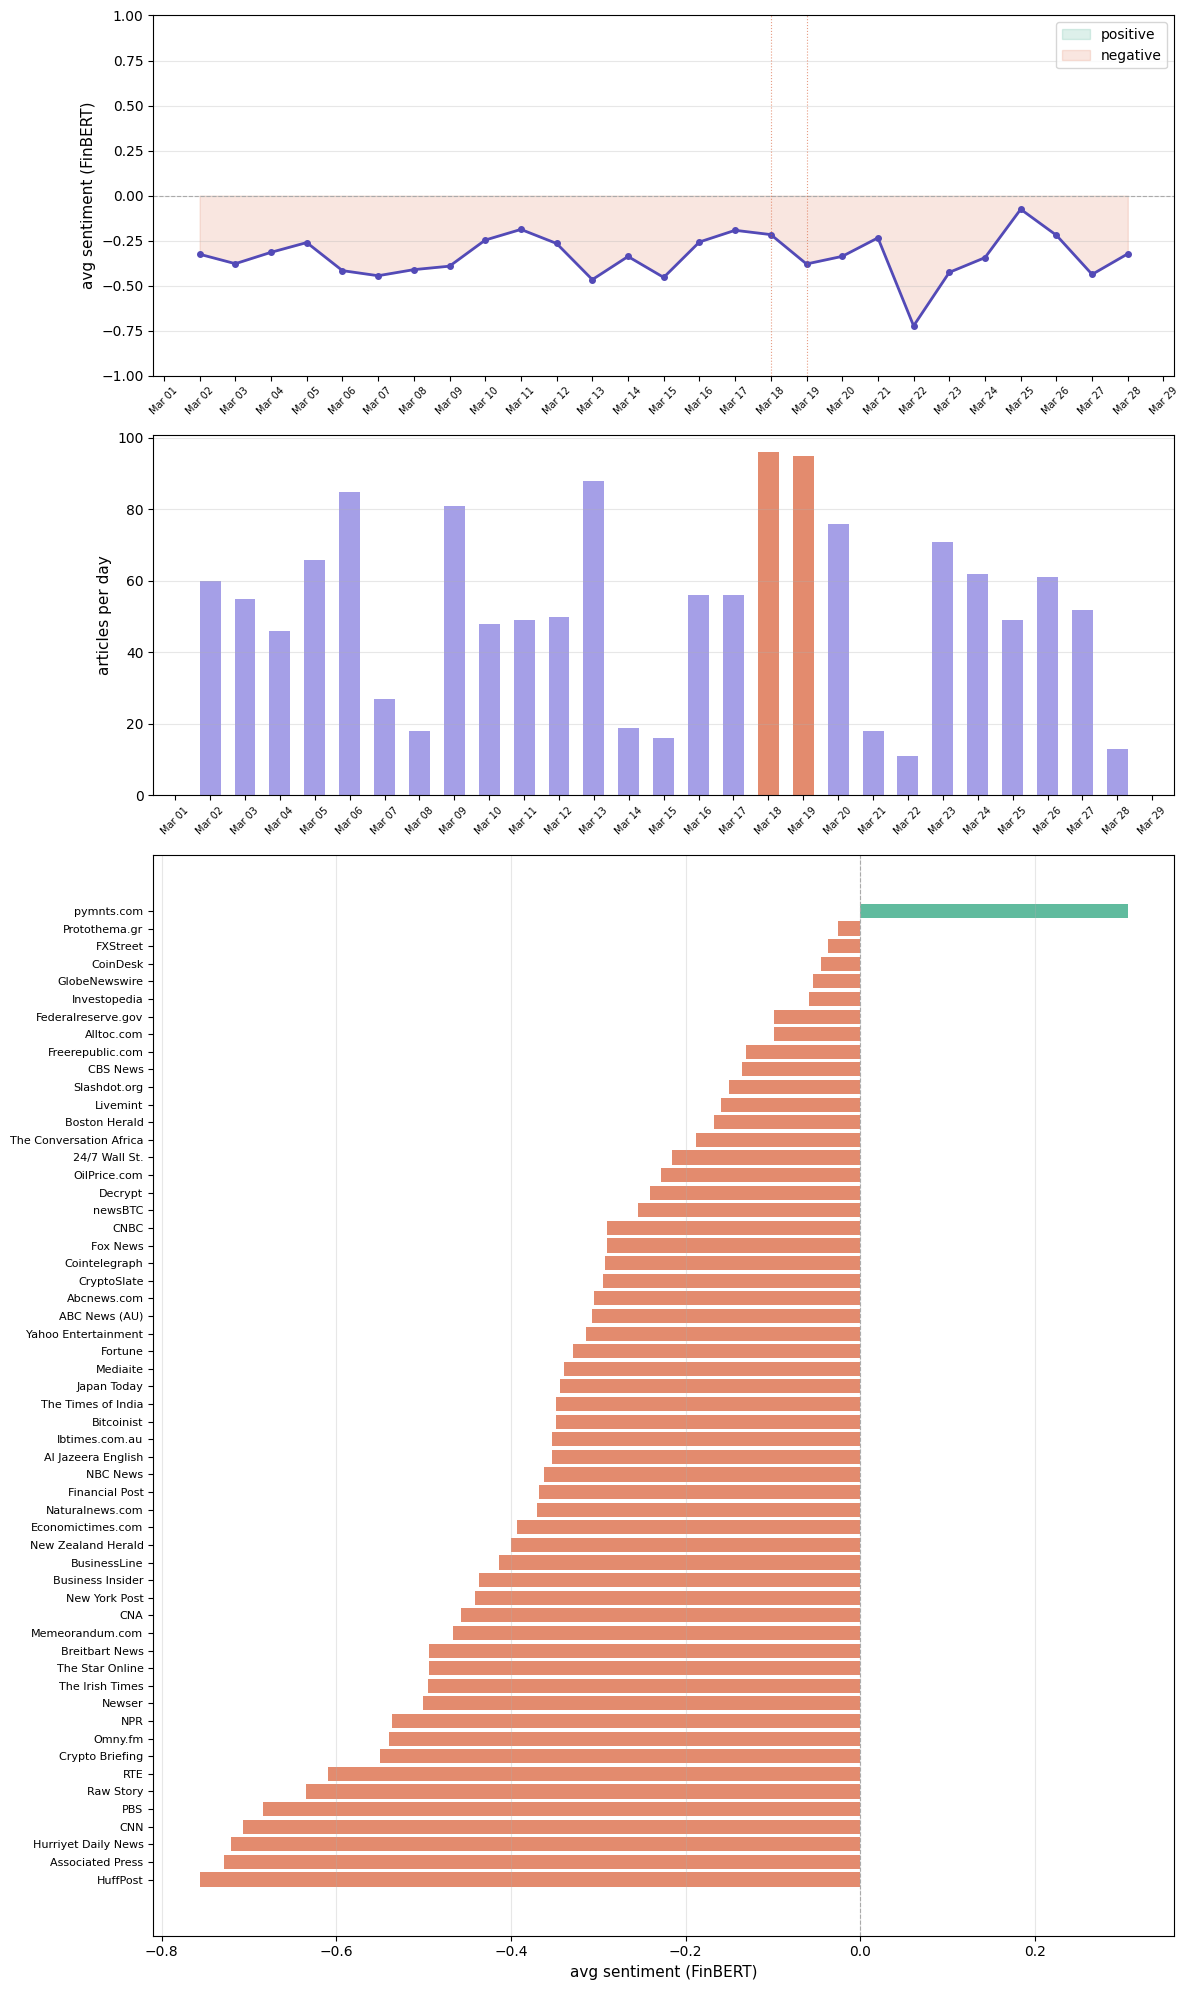

Chart saved as fed_sentiment_layer2.png


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 20), sharex=False,
                         gridspec_kw={"height_ratios": [1, 1, 3]})

# --- chart 1: sentiment over time ---
ax1 = axes[0]
ax1.plot(daily["published"], daily["avg_sentiment"], color="#534AB7", linewidth=2, marker="o", markersize=4)
ax1.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax1.fill_between(daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] >= 0), color="#1D9E75", alpha=0.15, label="positive")
ax1.fill_between(daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] < 0), color="#D85A30", alpha=0.15, label="negative")
for _, row in daily[daily["high_volume"]].iterrows():
    ax1.axvline(row["published"], color="#D85A30", linewidth=0.8, linestyle=":", alpha=0.6)
ax1.set_ylabel("avg sentiment (FinBERT)", fontsize=11)
ax1.set_ylim(-1, 1)
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, fontsize=7)

# --- chart 2: volume with heat score ---
ax2 = axes[1]
colors = ["#D85A30" if h else "#7F77DD" for h in daily["high_volume"]]
ax2.bar(daily["published"], daily["article_count"], color=colors, alpha=0.7, width=0.6)
ax2.set_ylabel("articles per day", fontsize=11)
ax2.grid(axis="y", alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, fontsize=7)

# --- chart 3: outlet comparison (fixed) ---
ax3 = axes[2]

# truncate long outlet names
outlet_sentiment["short_name"] = outlet_sentiment["source"].str[:30]

colors_outlet = ["#D85A30" if s < 0 else "#1D9E75" for s in outlet_sentiment["avg_sentiment"]]
ax3.barh(outlet_sentiment["short_name"], outlet_sentiment["avg_sentiment"], color=colors_outlet, alpha=0.7)
ax3.axvline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax3.set_xlabel("avg sentiment (FinBERT)", fontsize=11)
ax3.tick_params(axis="y", labelsize=8)
ax3.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fed_sentiment_layer2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as fed_sentiment_layer2.png")

In [27]:
print(f"Average daily articles: {mean_vol:.1f}")
print(f"Standard deviation: {std_vol:.1f}")
print(f"Anomaly threshold (1.5x std): {mean_vol + (1.5 * std_vol):.1f} articles")
print()
print(daily[["published", "article_count", "heat_score", "high_volume"]]
      .sort_values("heat_score", ascending=False)
      .head(10))

Average daily articles: 52.7
Standard deviation: 25.6
Anomaly threshold (1.5x std): 91.1 articles

    published  article_count  heat_score  high_volume
16 2026-03-18             96    1.691114         True
17 2026-03-19             95    1.652022         True
11 2026-03-13             88    1.378374        False
4  2026-03-06             85    1.261096        False
7  2026-03-09             81    1.104726        False
18 2026-03-20             76    0.909263        False
21 2026-03-23             71    0.713801        False
3  2026-03-05             66    0.518338        False
22 2026-03-24             62    0.361968        False
24 2026-03-26             61    0.322875        False


In [28]:
daily.to_csv("daily_sentiment.csv", index=False)
print("Saved daily_sentiment.csv")

Saved daily_sentiment.csv


In [33]:
daily.head()


,published,avg_sentiment,article_count,positive,negative,neutral,heat_score,high_volume
0,2026-03-02,-0.325061,60,8,30,22,0.283783,False
1,2026-03-03,-0.377513,55,6,30,19,0.088320,False
2,2026-03-04,-0.314382,46,8,23,15,-0.263513,False
3,2026-03-05,-0.260268,66,12,31,23,0.518338,False
4,2026-03-06,-0.416032,85,12,49,24,1.261096,False
